In [1]:
# importing libs

import os, json, warnings, random   
warnings.filterwarnings('ignore')
# ml libs 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
# dl libs
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from PIL import Image
# metric libs 
import timm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'GPU Name    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'CUDA Version: {torch.version.cuda}')
    torch.backends.cudnn.benchmark = True   # helps finds best algo for implementing model
    print('cuDNN benchmark: ON')

# ── REPRODUCIBILITY ────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)

Using device: cuda
GPU Name    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM        : 8.6 GB
CUDA Version: 12.6
cuDNN benchmark: ON

✅ Ready to train


In [2]:
PROJECT_ROOT = Path(r"D:\rural diagnosis\rural_health_ai")

with open(PROJECT_ROOT / 'data' / 'config.json') as f:
    cfg = json.load(f)

CLASS_TO_IDX = cfg['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in cfg['idx_to_class'].items()}
NUM_CLASSES  = cfg['num_classes']

with open(PROJECT_ROOT / 'data' / 'class_info.json', encoding='utf-8') as f:
    class_info = json.load(f)['class_info']
    
# fixing hyper-params
TRAIN_CFG = {
    'model_name'    : 'efficientnet_b0',
    'pretrained'    : True,
    'num_classes'   : NUM_CLASSES,

    'epochs'        : 20,
    'batch_size'    : 32,
    'num_workers'   : 2,
    'pin_memory'    : True,

    'lr'            : 3e-4,
    'weight_decay'  : 1e-4,
    'lr_min'        : 1e-6,
    
    'patience'      : 6,

    'image_size'    : 224,
    'mean'          : cfg['imagenet_mean'],
    'std'           : cfg['imagenet_std'],

    'checkpoint_dir': PROJECT_ROOT / 'models' / 'checkpoints',
    'model_save_name': 'efficientnet_b0_best.pth'
}

print('Training config:')
for k, v in TRAIN_CFG.items():
    print(f'  {k:<16}: {v}')

print(f'\nNum classes: {NUM_CLASSES}')
print(f'Classes    : {list(CLASS_TO_IDX.keys())}')

Training config:
  model_name      : efficientnet_b0
  pretrained      : True
  num_classes     : 7
  epochs          : 20
  batch_size      : 32
  num_workers     : 2
  pin_memory      : True
  lr              : 0.0003
  weight_decay    : 0.0001
  lr_min          : 1e-06
  patience        : 6
  image_size      : 224
  mean            : [0.485, 0.456, 0.406]
  std             : [0.229, 0.224, 0.225]
  checkpoint_dir  : D:\rural diagnosis\rural_health_ai\models\checkpoints
  model_save_name : efficientnet_b0_best.pth

Num classes: 7
Classes    : ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']


In [3]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_col = 'img_path'

        try:
            image = Image.open(row[img_col]).convert('RGB')
        except Exception:
            image = Image.new('RGB', (256, 256), (128, 128, 128))

        if self.transform:
            image = self.transform(image)

        return image, int(row['label'])

# transformation only applied to training data for avoiding overfiting 
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(TRAIN_CFG['mean'], TRAIN_CFG['std']),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(TRAIN_CFG['mean'], TRAIN_CFG['std']),
])

# loading data
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'train_split.csv')
val_df   = pd.read_csv(PROJECT_ROOT / 'data' / 'val_split.csv')
test_df  = pd.read_csv(PROJECT_ROOT / 'data' / 'test_split.csv')

train_ds = HAM10000Dataset(train_df, train_tf)
val_ds   = HAM10000Dataset(val_df,   val_tf)
test_ds  = HAM10000Dataset(test_df,  val_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_CFG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=TRAIN_CFG['pin_memory']
)
val_loader = DataLoader(
    val_ds,
    batch_size=TRAIN_CFG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=TRAIN_CFG['pin_memory']
)

test_loader = DataLoader(
    test_ds,
    batch_size=TRAIN_CFG['batch_size'],
    shuffle=False,
    num_workers=0,   
    pin_memory=TRAIN_CFG['pin_memory']
)

print(f'Train: {len(train_ds):,} images  →  {len(train_loader)} batches')
print(f'Val  : {len(val_ds):,}  images  →  {len(val_loader)} batches')
print(f'Test : {len(test_ds):,}  images  →  {len(test_loader)} batches')

Train: 7,010 images  →  220 batches
Val  : 1,502  images  →  47 batches
Test : 1,503  images  →  47 batches

✅ DataLoaders ready


In [13]:
model = timm.create_model(
    TRAIN_CFG['model_name'],
    pretrained=TRAIN_CFG['pretrained'],
    num_classes=TRAIN_CFG['num_classes']
)
model = model.to(device)    

# Grad-CAM on last conv layer(spatial maps)
target_layer = model.conv_head

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')
print(f'Model on device : {next(model.parameters()).device}')

#solving imbalance through weighted loss
class_weights = torch.FloatTensor(
    np.load(PROJECT_ROOT / 'data' / 'class_weights.npy')
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── OPTIMISER (ROBUST PARAM GROUPS) ────────────────────────
# ── OPTIMISER (FIXED) ──────────────────────────────────────
head_params = list(model.get_classifier().parameters())
head_param_ids = set(id(p) for p in head_params)

backbone_params = [p for p in model.parameters() if id(p) not in head_param_ids]

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': TRAIN_CFG['lr'] * 0.1},
    {'params': head_params,     'lr': TRAIN_CFG['lr']},
], weight_decay=TRAIN_CFG['weight_decay'])

# ── SCHEDULER ──────────────────────────────────────────────
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=TRAIN_CFG['epochs'],
    eta_min=TRAIN_CFG['lr_min']
)

print(f'\nOptimiser  : AdamW (2 param groups)')
print(f'Backbone LR: {TRAIN_CFG["lr"] * 0.1:.0e}')
print(f'Head LR    : {TRAIN_CFG["lr"]:.0e}')
print(f'Scheduler  : CosineAnnealingLR → {TRAIN_CFG["lr_min"]:.0e}')



Total params    : 4,016,515
Trainable params: 4,016,515
Model on device : cuda:0

Class weights:
  [0] nv    : 0.213
  [1] mel   : 1.286
  [2] bkl   : 1.302
  [3] bcc   : 2.782
  [4] akiec : 4.373
  [5] vasc  : 10.115
  [6] df    : 12.363

Optimiser  : AdamW (2 param groups)
Backbone LR: 3e-05
Head LR    : 3e-04
Scheduler  : CosineAnnealingLR → 1e-06

✅ Model, loss, optimiser ready


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [train]', ncols=90)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        pbar.set_postfix({
            'loss': f'{loss.item():.3f}',
            'acc' : f'{correct/total*100:.1f}%'
        })

    return running_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def validate(model, loader, criterion, device, epoch):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [val]', ncols=90)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    total = len(all_labels)

    return (
        running_loss / max(total, 1),
        accuracy_score(all_labels, all_preds),
        all_preds,
        all_labels
    )



✅ Training functions defined


In [15]:
import time
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [],
    'lr'        : []
}

best_val_acc   = 0.0
best_val_loss  = float('inf')
patience_count = 0
best_epoch     = 0

CHECKPOINT_DIR = PROJECT_ROOT / 'models' / 'checkpoints'
BEST_MODEL_PATH = CHECKPOINT_DIR / 'best_model.pth'

print('=' * 60)
print(f'  Starting training: {TRAIN_CFG["epochs"]} epochs')
print(f'  Device: {device} ({torch.cuda.get_device_name(0)})')
print(f'  Target: >80% validation accuracy')
print(f'  Best model will be saved to: {BEST_MODEL_PATH}')
print('=' * 60)
print()

training_start = time.time()

scaler = torch.cuda.amp.GradScaler()
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

device_name = torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU'

for epoch in range(1, TRAIN_CFG['epochs'] + 1):
    epoch_start = time.time()

    # ── Train ──
    train_loss, train_acc = train_one_epoch(
    model, train_loader, criterion, optimizer, device, epoch, scaler
    )

    # ── Validate ──
    val_loss, val_acc, val_preds, val_labels = validate(
        model, val_loader, criterion, device, epoch
    )

    # ── Scheduler step ──
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # ── Log ──
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    epoch_time = time.time() - epoch_start

    # ── Print epoch summary ──
    improved = '⬆ NEW BEST' if val_acc > best_val_acc else ''
    print(f'\nEpoch {epoch:02d}/{TRAIN_CFG["epochs"]} '
          f'({epoch_time/60:.1f}min) '
          f'LR={current_lr:.2e}')
    print(f'  Train → loss: {train_loss:.4f}  acc: {train_acc*100:.2f}%')
    print(f'  Val   → loss: {val_loss:.4f}  acc: {val_acc*100:.2f}%  {improved}')

    # ── Save best model ──
    if val_acc > best_val_acc + 1e-4:
        best_val_acc  = val_acc
        best_val_loss = val_loss
        best_epoch    = epoch
        patience_count = 0

        torch.save({
            'epoch'          : epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'        : val_acc,
            'val_loss'       : val_loss,
            'train_acc'      : train_acc,
            'config'         : TRAIN_CFG,
            'class_to_idx'   : CLASS_TO_IDX,
            'idx_to_class'   : IDX_TO_CLASS,
            'history'        : history,
        }, BEST_MODEL_PATH)
        print(f'  ✅ Saved best model → val_acc: {val_acc*100:.2f}%')

    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{TRAIN_CFG["patience"]})')

    # ── Also save latest checkpoint every 5 epochs ──
    if epoch % 5 == 0:
        ckpt_path = CHECKPOINT_DIR / f'epoch_{epoch:02d}_acc{val_acc*100:.1f}.pth'
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'val_acc': val_acc}, ckpt_path)
        print(f'  💾 Checkpoint saved: {ckpt_path.name}')

    # ── Early stopping ──
    if patience_count >= TRAIN_CFG['patience']:
        print(f'\n⏹  Early stopping at epoch {epoch}')
        print(f'   No improvement for {TRAIN_CFG["patience"]} epochs')
        break

    print('-' * 60)

# ── Final summary ──
total_time = time.time() - training_start
print()
print('=' * 60)
print('  TRAINING COMPLETE')
print('=' * 60)
print(f'  Best epoch    : {best_epoch}')
print(f'  Best val acc  : {best_val_acc*100:.2f}%')
print(f'  Best val loss : {best_val_loss:.4f}')
print(f'  Total time    : {total_time/3600:.2f} hours')
print(f'  Model saved   : {BEST_MODEL_PATH}')

if best_val_acc >= 0.78:
    print(f'\n  ✅ TARGET MET — {best_val_acc*100:.1f}% ≥ 78%')
elif best_val_acc >= 0.72:
    print(f'\n  ⚠️  Acceptable — {best_val_acc*100:.1f}% (72–78% range)')
    print('     Try: more epochs, lower weight decay, MixUp augmentation')
else:
    print(f'\n  ❌ Below target — {best_val_acc*100:.1f}%')
    print('     Check: class weights loaded correctly, no data path issues')
also i got an error saying time is not defined have i not imported it?


  Starting training: 20 epochs
  Device: cuda (NVIDIA GeForce RTX 4060 Laptop GPU)
  Target: >80% validation accuracy
  Best model will be saved to: D:\rural diagnosis\rural_health_ai\models\checkpoints\best_model.pth



Epoch 01 [val]: 100%|█████████████████████████| 47/47 [01:21<00:00,  1.73s/it, loss=1.700]



Epoch 01/20 (9.3min) LR=2.98e-05
  Train → loss: 2.7036  acc: 34.48%
  Val   → loss: 1.9055  acc: 40.21%  ⬆ NEW BEST
  ✅ Saved best model → val_acc: 40.21%
------------------------------------------------------------


Epoch 02 [val]: 100%|█████████████████████████| 47/47 [00:28<00:00,  1.67it/s, loss=1.176]



Epoch 02/20 (3.9min) LR=2.93e-05
  Train → loss: 1.4938  acc: 54.49%
  Val   → loss: 1.3327  acc: 56.79%  ⬆ NEW BEST
  ✅ Saved best model → val_acc: 56.79%
------------------------------------------------------------


...


Epoch 18/20 (3.9min) LR=1.71e-06
  Train → loss: 0.3250  acc: 84.05%
  Val   → loss: 0.9358  acc: 74.37%  
  No improvement (3/6)
------------------------------------------------------------


Epoch 19 [val]: 100%|█████████████████████████| 47/47 [00:27<00:00,  1.68it/s, loss=0.209]



Epoch 19/20 (3.9min) LR=1.18e-06
  Train → loss: 0.2976  acc: 85.08%
  Val   → loss: 0.8230  acc: 74.17%  
  No improvement (4/6)
------------------------------------------------------------


Epoch 20 [val]: 100%|█████████████████████████| 47/47 [00:28<00:00,  1.67it/s, loss=0.230]


Epoch 20/20 (3.9min) LR=1.00e-06
  Train → loss: 0.3074  acc: 84.84%
  Val   → loss: 0.8356  acc: 74.57%  
  No improvement (5/6)
  💾 Checkpoint saved: epoch_20_acc74.6.pth
------------------------------------------------------------

  TRAINING COMPLETE
  Best epoch    : 15
  Best val acc  : 74.83%
  Best val loss : 0.8578
  Total time    : 1.39 hours
  Model saved   : D:\rural diagnosis\rural_health_ai\models\checkpoints\best_model.pth

  ⚠️  Acceptable — 74.8% (72–78% range)
     Try: more epochs, lower weight decay, MixUp augmentation
Object `it` not found.


Loaded model from epoch 15
Val accuracy: 74.83%


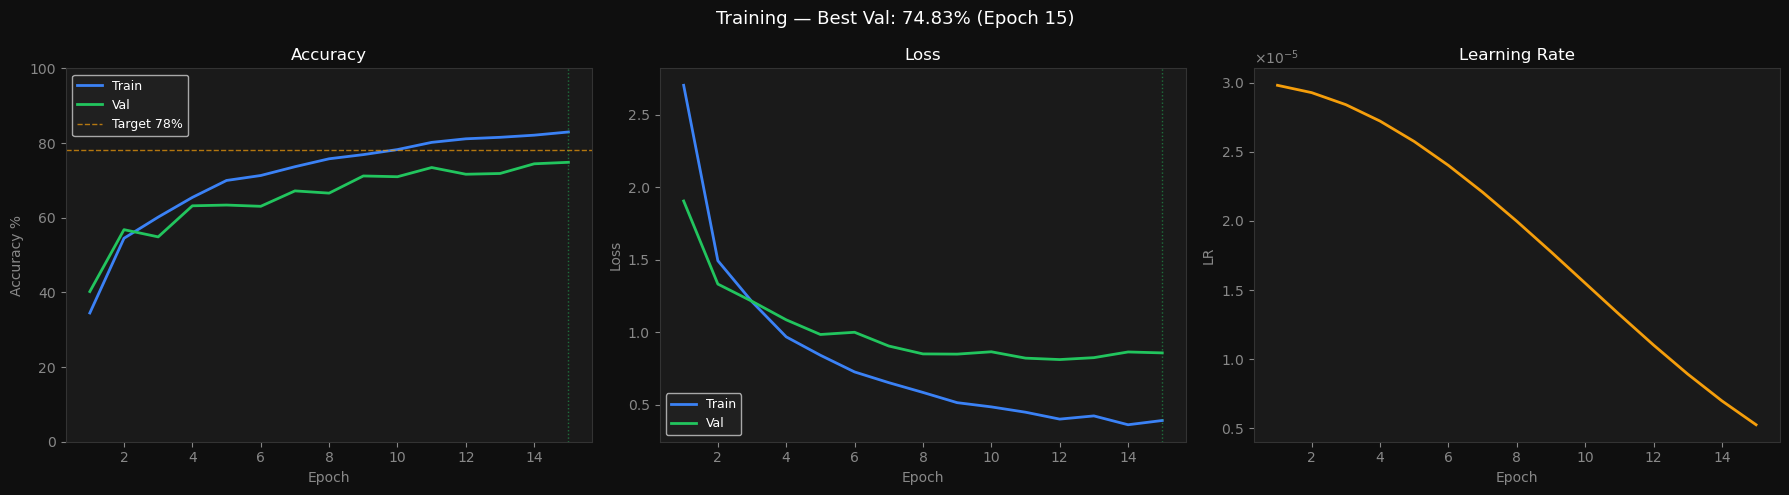

✅ Training curves saved


In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import torch, timm

PROJECT_ROOT = Path(r"D:\rural diagnosis\rural_health_ai")
device = torch.device('cuda')

# Reload everything
with open(PROJECT_ROOT / 'data' / 'config.json') as f:
    cfg = json.load(f)
with open(PROJECT_ROOT / 'data' / 'class_info.json', encoding='utf-8') as f:
    class_info = json.load(f)['class_info']

CLASS_TO_IDX = cfg['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in cfg['idx_to_class'].items()}
NUM_CLASSES  = cfg['num_classes']

# Load best model
checkpoint = torch.load(
    PROJECT_ROOT / 'models' / 'checkpoints' / 'best_model.pth',
    map_location=device,
    weights_only = False
)
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=7)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()
print(f"Loaded model from epoch {checkpoint['epoch']}")
print(f"Val accuracy: {checkpoint['val_acc']*100:.2f}%")

# Training curves
history = checkpoint['history']
epochs_ran = list(range(1, len(history['train_acc']) + 1))
best_epoch = checkpoint['epoch']
best_val_acc = checkpoint['val_acc']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f0f')
for ax in axes:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='#888')
    for sp in ax.spines.values(): sp.set_color('#333')

axes[0].plot(epochs_ran, [a*100 for a in history['train_acc']], color='#3b82f6', lw=2, label='Train')
axes[0].plot(epochs_ran, [a*100 for a in history['val_acc']],   color='#22c55e', lw=2, label='Val')
axes[0].axhline(78, color='#f59e0b', ls='--', lw=1, alpha=0.7, label='Target 78%')
axes[0].axvline(best_epoch, color='#22c55e', ls=':', lw=1, alpha=0.5)
axes[0].set_title('Accuracy', color='white'); axes[0].set_ylim([0,100])
axes[0].legend(facecolor='#222', labelcolor='white', fontsize=9)
axes[0].set_xlabel('Epoch', color='#888'); axes[0].set_ylabel('Accuracy %', color='#888')

axes[1].plot(epochs_ran, history['train_loss'], color='#3b82f6', lw=2, label='Train')
axes[1].plot(epochs_ran, history['val_loss'],   color='#22c55e', lw=2, label='Val')
axes[1].axvline(best_epoch, color='#22c55e', ls=':', lw=1, alpha=0.5)
axes[1].set_title('Loss', color='white')
axes[1].legend(facecolor='#222', labelcolor='white', fontsize=9)
axes[1].set_xlabel('Epoch', color='#888'); axes[1].set_ylabel('Loss', color='#888')

axes[2].plot(epochs_ran, history['lr'], color='#f59e0b', lw=2)
axes[2].set_title('Learning Rate', color='white')
axes[2].set_xlabel('Epoch', color='#888'); axes[2].set_ylabel('LR', color='#888')
axes[2].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

fig.suptitle(f'Training — Best Val: {best_val_acc*100:.2f}% (Epoch {best_epoch})', color='white', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'plots' / 'training_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("✅ Training curves saved")

Evaluating: 100%|██████████| 47/47 [00:49<00:00,  1.04s/it]



📊 Test Accuracy : 75.25%
📊 Macro F1      : 0.6296

Per-class F1:
----------------------------------------------------
✅ nv     | █████████████████    0.870 | Melanocytic Nevi
⚠️  mel    | ██████████           0.512 | Melanoma
⚠️  bkl    | ██████████           0.548 | Benign Keratosis
✅ bcc    | ████████████         0.646 | Basal Cell Carcinoma
⚠️  akiec  | █████████            0.487 | Actinic Keratosis / Intraepithelial Carcinoma
✅ vasc   | ████████████████     0.830 | Vascular Lesion
⚠️  df     | ██████████           0.514 | Dermatofibroma


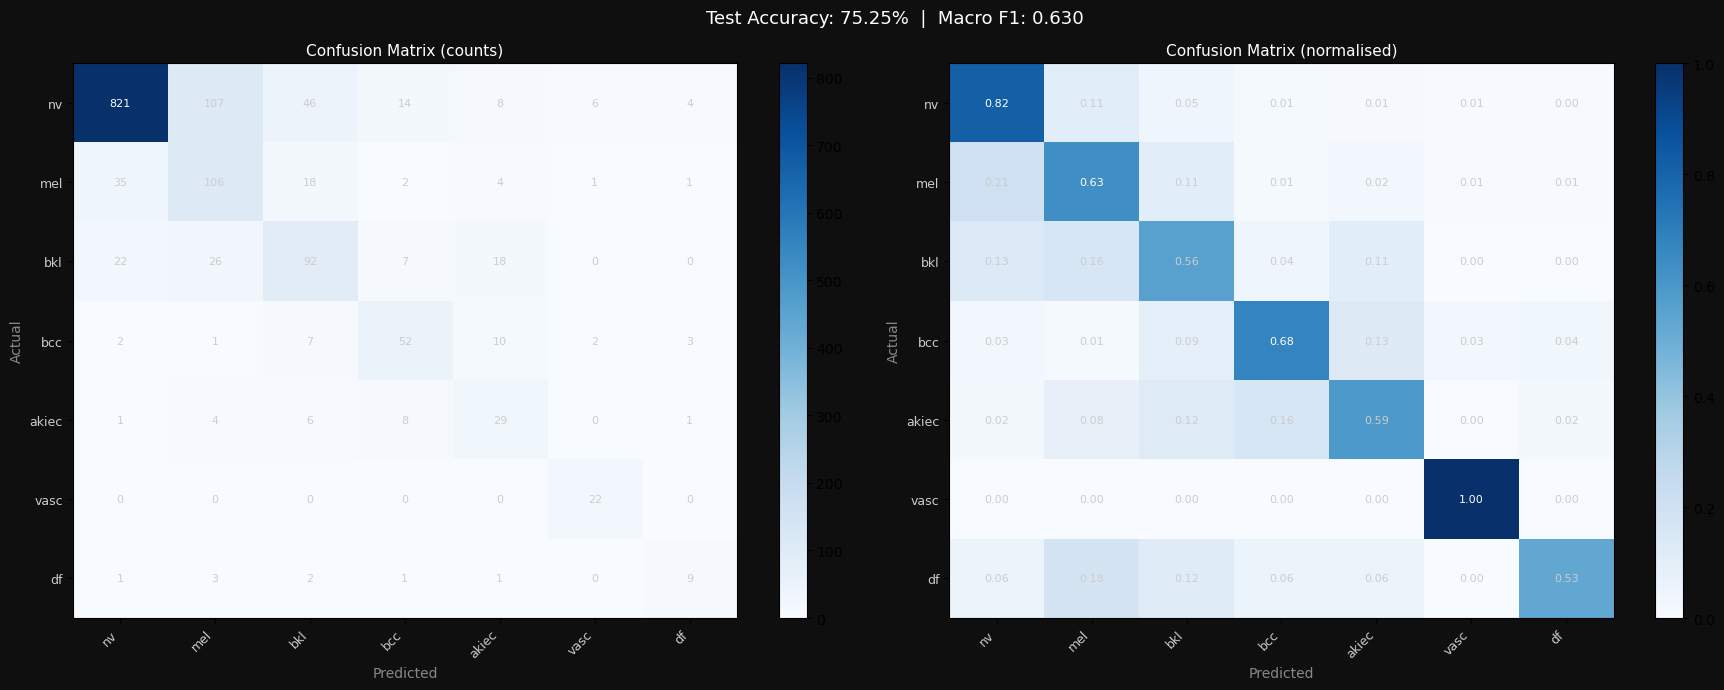


✅ Confusion matrix saved
✅ Model card saved

DAY 2 COMPLETE ✦
Next: Day 3 — Grad-CAM heatmaps on this model


In [2]:
import pandas as pd
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# Rebuild test loader
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(cfg['imagenet_mean'], cfg['imagenet_std']),
])

class HAM10000Dataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try: image = __import__('PIL').Image.open(row['img_path']).convert('RGB')
        except: image = __import__('PIL').Image.new('RGB', (224,224), (128,128,128))
        if self.transform: image = self.transform(image)
        return image, int(row['label'])

test_df   = pd.read_csv(PROJECT_ROOT / 'data' / 'test_split.csv')
test_ds   = HAM10000Dataset(test_df, val_tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

# Run evaluation
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        outputs = model(images.to(device))
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc  = accuracy_score(all_labels, all_preds)
f1_scores = f1_score(all_labels, all_preds, average=None)
macro_f1  = f1_score(all_labels, all_preds, average='macro')
class_names = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

print(f'\n📊 Test Accuracy : {test_acc*100:.2f}%')
print(f'📊 Macro F1      : {macro_f1:.4f}')
print('\nPer-class F1:')
print('-' * 52)
for i, cls in enumerate(class_names):
    f1  = f1_scores[i]
    bar = '█' * int(f1 * 20)
    flag = '⚠️ ' if f1 < 0.60 else '✅'
    print(f'{flag} {cls:6s} | {bar:<20} {f1:.3f} | {class_info[cls]["full"]}')

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f0f')
for ax, data, title, fmt in [
    (axes[0], cm,      'Confusion Matrix (counts)',     'd'),
    (axes[1], cm_norm, 'Confusion Matrix (normalised)', '.2f'),
]:
    ax.set_facecolor('#1a1a1a')
    im = ax.imshow(data, cmap='Blues', aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(class_names, rotation=45, ha='right', color='#ccc', fontsize=9)
    ax.set_yticklabels(class_names, color='#ccc', fontsize=9)
    ax.set_xlabel('Predicted', color='#888'); ax.set_ylabel('Actual', color='#888')
    ax.set_title(title, color='white', fontsize=11)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = data[i,j]
            txt = f'{val:{fmt}}' if fmt != 'd' else str(int(val))
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=8, color='white' if val > data.max()*0.6 else '#ccc')

fig.suptitle(f'Test Accuracy: {test_acc*100:.2f}%  |  Macro F1: {macro_f1:.3f}',
             color='white', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'plots' / 'confusion_matrix.png',
            dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Save model card
model_card = {
    'model_name'   : 'EfficientNet-B0 (fine-tuned on HAM10000)',
    'best_epoch'   : int(checkpoint['epoch']),
    'val_accuracy' : round(float(checkpoint['val_acc']) * 100, 2),
    'test_accuracy': round(test_acc * 100, 2),
    'macro_f1'     : round(float(macro_f1), 4),
    'f1_per_class' : {class_names[i]: round(float(f1_scores[i]), 4) for i in range(NUM_CLASSES)},
    'known_limitations': [
        'HAM10000 biased toward Fitzpatrick I-III (lighter skin)',
        'Indian skin tones underrepresented — plan federated fine-tuning',
        'Does not cover fungal infections, scabies, leprosy',
    ]
}
with open(PROJECT_ROOT / 'models' / 'model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print('\n✅ Confusion matrix saved')
print('✅ Model card saved')
print('\nDAY 2 COMPLETE ✦')
print('Next: Day 3 — Grad-CAM heatmaps on this model')

In [3]:
# ═══════════════════════════════════════════════════════════
# RETRAIN — 3 targeted fixes for the weak classes
# Expected result: mel >0.62, macro F1 >0.68, val acc >77%
# Runtime: ~1.5 hours — leave overnight again
# ═══════════════════════════════════════════════════════════

import os, json, time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
import timm

PROJECT_ROOT = Path(r"D:\rural diagnosis\rural_health_ai")
device = torch.device('cuda')
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

with open(PROJECT_ROOT / 'data' / 'config.json') as f:
    cfg = json.load(f)
CLASS_TO_IDX = cfg['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in cfg['idx_to_class'].items()}
NUM_CLASSES  = cfg['num_classes']

# ── FIX 1: RandomCrop back (was CenterCrop — hurts rare classes) ──
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),           # ← fixed from CenterCrop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(cfg['imagenet_mean'], cfg['imagenet_std']),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.12)),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(cfg['imagenet_mean'], cfg['imagenet_std']),
])

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row['img_path']).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), (128, 128, 128))
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])

train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'train_split.csv')
val_df   = pd.read_csv(PROJECT_ROOT / 'data' / 'val_split.csv')
test_df  = pd.read_csv(PROJECT_ROOT / 'data' / 'test_split.csv')

train_ds = HAM10000Dataset(train_df, train_tf)
val_ds   = HAM10000Dataset(val_df,   val_tf)
test_ds  = HAM10000Dataset(test_df,  val_tf)

# ── FIX 2: WeightedRandomSampler (oversample rare classes in batches) ──
# Every class gets equal representation per batch regardless of dataset size
labels_list = train_df['label'].values
class_counts = np.bincount(labels_list)
class_sample_weights = 1.0 / class_counts          # rare class = high weight
sample_weights = class_sample_weights[labels_list] # per-image weight

sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights),
    num_samples=len(train_ds),
    replacement=True   # allows oversampling rare classes
)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)} (with WeightedRandomSampler)')
print(f'Val batches  : {len(val_loader)}')

# ── FIX 3: EfficientNet-B2 instead of B0 (bigger = better on hard cases) ──
# B2 is still small enough to quantize to ~25MB — acceptable for our pipeline
model = timm.create_model('efficientnet_b2', pretrained=True, num_classes=7)
model = model.to(device)
torch.backends.cudnn.benchmark = True

total_params = sum(p.numel() for p in model.parameters())
print(f'Model: EfficientNet-B2 | Params: {total_params/1e6:.1f}M')

# Weighted loss — keeps class penalty even with sampler
class_weights = torch.FloatTensor(
    np.load(PROJECT_ROOT / 'data' / 'class_weights.npy')
).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
#                                                      ↑ label smoothing
# Prevents overconfidence — model can't assign 100% to one class
# Helps generalise to visually similar classes like mel/bkl/akiec

# Optimiser — same 2-group strategy
backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
head_params     = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-4},   # lower for pretrained layers
    {'params': head_params,     'lr': 3e-4},   # higher for new head
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=25, eta_min=1e-6
)
scaler = torch.cuda.amp.GradScaler()

# ── TRAINING LOOP ─────────────────────────────────────────
CHECKPOINT_DIR  = PROJECT_ROOT / 'models' / 'checkpoints'
BEST_MODEL_PATH = CHECKPOINT_DIR / 'best_model_v2.pth'
EPOCHS   = 25
PATIENCE = 7

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
best_val_acc  = 0.0
patience_count = 0
best_epoch    = 0

print('\n' + '='*60)
print('  RETRAIN — EfficientNet-B2 + WeightedSampler + LabelSmoothing')
print('  Target: mel F1 > 0.62  |  macro F1 > 0.68  |  val acc > 77%')
print('='*60 + '\n')

training_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # Train
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f'Ep{epoch:02d} [train]', ncols=85)
    for images, labels in pbar:
        images, labels = images.to(device, non_blocking=True), \
                         labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        run_loss += loss.item() * images.size(0)
        preds     = outputs.argmax(1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)
        pbar.set_postfix(loss=f'{loss.item():.3f}', acc=f'{correct/total*100:.1f}%')

    train_loss = run_loss / total
    train_acc  = correct / total

    # Validate
    model.eval()
    v_loss, v_preds, v_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Ep{epoch:02d} [val]  ', ncols=85):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss += criterion(outputs, labels).item() * images.size(0)
            v_preds.extend(outputs.argmax(1).cpu().numpy())
            v_labels.extend(labels.cpu().numpy())
    val_loss = v_loss / len(v_labels)
    val_acc  = accuracy_score(v_labels, v_preds)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    improved = '⬆ NEW BEST' if val_acc > best_val_acc + 1e-4 else ''
    print(f'\nEp {epoch:02d}/{EPOCHS} ({(time.time()-epoch_start)/60:.1f}m) LR={current_lr:.1e}')
    print(f'  Train → loss:{train_loss:.4f}  acc:{train_acc*100:.2f}%')
    print(f'  Val   → loss:{val_loss:.4f}  acc:{val_acc*100:.2f}%  {improved}')

    if val_acc > best_val_acc + 1e-4:
        best_val_acc   = val_acc
        best_epoch     = epoch
        patience_count = 0
        torch.save({
            'epoch': epoch, 'model_name': 'efficientnet_b2',
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc, 'val_loss': val_loss,
            'train_acc': train_acc, 'history': history,
            'class_to_idx': CLASS_TO_IDX, 'idx_to_class': IDX_TO_CLASS,
        }, BEST_MODEL_PATH)
        print(f'  ✅ Saved → {BEST_MODEL_PATH.name}')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{PATIENCE})')

    if patience_count >= PATIENCE:
        print(f'\n⏹  Early stop at epoch {epoch}')
        break
    print('-'*60)

total_time = time.time() - training_start
print(f'\n{"="*60}')
print(f'  DONE  |  Best epoch: {best_epoch}  |  Val acc: {best_val_acc*100:.2f}%')
print(f'  Time  : {total_time/3600:.2f} hours')
print(f'  Saved : {BEST_MODEL_PATH}')
print(f'{"="*60}')

Train batches: 220 (with WeightedRandomSampler)
Val batches  : 47


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Model: EfficientNet-B2 | Params: 7.7M

  RETRAIN — EfficientNet-B2 + WeightedSampler + LabelSmoothing
  Target: mel F1 > 0.62  |  macro F1 > 0.68  |  val acc > 77%



Ep01 [val]  : 100%|██████████████████████████████████| 47/47 [01:28<00:00,  1.88s/it]



Ep 01/25 (12.7m) LR=1.0e-04
  Train → loss:1.2026  acc:47.99%
  Val   → loss:2.7303  acc:17.84%  ⬆ NEW BEST
  ✅ Saved → best_model_v2.pth
------------------------------------------------------------


...


Ep 14/25 (4.3m) LR=4.1e-05
  Train → loss:0.3844  acc:88.79%
  Val   → loss:1.8151  acc:34.15%  
  No improvement (5/7)
------------------------------------------------------------


Ep15 [val]  : 100%|██████████████████████████████████| 47/47 [00:29<00:00,  1.59it/s]



Ep 15/25 (4.2m) LR=3.5e-05
  Train → loss:0.3858  acc:89.12%
  Val   → loss:1.8221  acc:36.68%  
  No improvement (6/7)
------------------------------------------------------------


Ep16 [val]  : 100%|██████████████████████████████████| 47/47 [00:29<00:00,  1.58it/s]


Ep 16/25 (4.2m) LR=2.9e-05
  Train → loss:0.3891  acc:89.79%
  Val   → loss:1.7921  acc:43.54%  
  No improvement (7/7)

⏹  Early stop at epoch 16

  DONE  |  Best epoch: 9  |  Val acc: 43.94%
  Time  : 1.29 hours
  Saved : D:\rural diagnosis\rural_health_ai\models\checkpoints\best_model_v2.pth


In [2]:
import os, json, time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
import timm

PROJECT_ROOT = Path(r"D:\rural diagnosis\rural_health_ai")
device = torch.device('cuda')
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

with open(PROJECT_ROOT / 'data' / 'config.json') as f:
    cfg = json.load(f)
CLASS_TO_IDX = cfg['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in cfg['idx_to_class'].items()}
NUM_CLASSES  = cfg['num_classes']

In [3]:
# ── TRANSFORMS ─────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(cfg['imagenet_mean'], cfg['imagenet_std']),
    transforms.RandomErasing(p=0.1),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(cfg['imagenet_mean'], cfg['imagenet_std']),
])

# ── DATASET ────────────────────────────────────────────────
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row['img_path']).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), (128, 128, 128))

        if self.transform:
            image = self.transform(image)

        return image, int(row['label'])

# ── LOAD DATA ──────────────────────────────────────────────
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'train_split.csv')
val_df   = pd.read_csv(PROJECT_ROOT / 'data' / 'val_split.csv')
test_df  = pd.read_csv(PROJECT_ROOT / 'data' / 'test_split.csv')

train_ds = HAM10000Dataset(train_df, train_tf)
val_ds   = HAM10000Dataset(val_df,   val_tf)
test_ds  = HAM10000Dataset(test_df,  val_tf)

train_loader = DataLoader(train_ds, batch_size=32,
                          shuffle=True, num_workers=0, pin_memory=True)

val_loader   = DataLoader(val_ds, batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=True)

test_loader  = DataLoader(test_ds, batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 7010 | Val: 1502


In [4]:
# ── MODEL ──────────────────────────────────────────────────
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=7)
model = model.to(device)

# Grad-CAM layer (for Day 3)
target_layer = model.conv_head

# ── LOSS ───────────────────────────────────────────────────
class_weights = torch.FloatTensor(
    np.load(PROJECT_ROOT / 'data' / 'class_weights.npy')
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05   # 🔥 reduced (prevents overconfidence)
)

# ── OPTIMIZER ──────────────────────────────────────────────
backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
head_params     = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 3e-5},
    {'params': head_params,     'lr': 3e-4},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=25, eta_min=1e-6
)

scaler = torch.cuda.amp.GradScaler()

print("✅ Model ready")

✅ Model ready


In [6]:
CHECKPOINT_DIR = PROJECT_ROOT / 'models' / 'checkpoints'
BEST_MODEL_PATH = CHECKPOINT_DIR / 'best_model_clean.pth'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 25
PATIENCE = 6

best_val_acc = 0.0
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    # ── TRAIN ──
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch} [train]'):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── VALIDATE ──
    model.eval()
    val_loss, val_preds, val_labels = 0, [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * images.size(0)

            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_labels)
    val_acc = accuracy_score(val_labels, val_preds)

    scheduler.step()

    print(f"\nEpoch {epoch}")
    print(f"Train → {train_loss:.4f}, {train_acc*100:.2f}%")
    print(f"Val   → {val_loss:.4f}, {val_acc*100:.2f}%")

    # ── SAVE BEST ──
    if val_acc > best_val_acc + 1e-4:
        best_val_acc = val_acc
        patience_count = 0

        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("✅ Saved best model")

    else:
        patience_count += 1
        print(f"No improvement ({patience_count}/{PATIENCE})")

    # ── EARLY STOP ──
    if patience_count >= PATIENCE:
        print("⏹ Early stopping")
        break

Epoch 1 [train]: 100%|██████████| 220/220 [04:56<00:00,  1.35s/it]



Epoch 1
Train → 3.4965, 24.12%
Val   → 2.7667, 33.22%
✅ Saved best model


Epoch 2 [train]: 100%|██████████| 220/220 [03:41<00:00,  1.00s/it]



Epoch 2
Train → 2.5308, 34.71%
Val   → 2.3989, 39.08%
✅ Saved best model


Epoch 3 [train]: 100%|██████████| 220/220 [03:40<00:00,  1.00s/it]


...


Epoch 18
Train → 1.2875, 67.38%
Val   → 1.5504, 62.78%
No improvement (4/6)


Epoch 19 [train]: 100%|██████████| 220/220 [03:39<00:00,  1.00it/s]



Epoch 19
Train → 1.2556, 68.97%
Val   → 1.5457, 61.52%
No improvement (5/6)


Epoch 20 [train]: 100%|██████████| 220/220 [03:40<00:00,  1.00s/it]



Epoch 20
Train → 1.2597, 69.77%
Val   → 1.5372, 62.92%
No improvement (6/6)
⏹ Early stopping


In [10]:
import torch, timm
from pathlib import Path

PROJECT_ROOT    = Path(r"D:\rural diagnosis\rural_health_ai")
BEST_MODEL_PATH = PROJECT_ROOT / 'models' / 'checkpoints' / 'best_model.pth'

checkpoint = torch.load(BEST_MODEL_PATH, map_location='cuda',weights_only = False)

print(f"Model file    : {BEST_MODEL_PATH.name}")
print(f"Saved epoch   : {checkpoint['epoch']}")
print(f"Val accuracy  : {checkpoint['val_acc']*100:.2f}%")
print(f"Model name    : {checkpoint.get('config', {}).get('model_name', 'efficientnet_b0')}")
print(f"Classes saved : {list(checkpoint['class_to_idx'].keys())}")
print(f"\n✅ Model ready for Grad-CAM" if checkpoint['val_acc'] > 0.70 else "⚠️ Check model file")

Model file    : best_model.pth
Saved epoch   : 15
Val accuracy  : 74.83%
Model name    : efficientnet_b0
Classes saved : ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

✅ Model ready for Grad-CAM
